# CNN STUDY (Denoising Dirty Documents)

### Experiment Summary

#### 1. Optimizer / Epoch

| Optimizer | Epoch | 목적                 |
| --------- | ----: | ------------------ |
| Adam      |    50 | Epoch에 따른 성능 변화 확인 |
| Adam      |   100 | Epoch에 따른 성능 변화 확인 |
| SGD       |    50 | Epoch에 따른 성능 변화 확인 |
| SGD       |   100 | Epoch에 따른 성능 변화 확인 |

* Adam이 SGD보다 낮은 Validation Loss를 기록
* Epoch 증가에 따른 성능 변화 확인

#### 2. SGD Learning Rate

| Optimizer | Learning Rate | Epoch |
| --------- | ------------: | ----: |
| SGD       |          0.01 |   100 |
| SGD       |           0.1 |   100 |

* Learning Rate에 따른 학습 성능 비교
* Learning Rate에 따라 학습 결과에 차이가 있음을 확인

#### 3. Loss Function

| Loss Function | Best Validation Loss | Best Epoch |
| ------------- | -------------------: | ---------: |
| MSE           |             0.001178 |        100 |
| L1            |             0.012335 |        100 |
| SmoothL1      |             0.000657 |         96 |

SmoothL1이 가장 낮은 Validation Loss를 기록하여 이후 실험에 사용.

#### 4. Skip Connection

| Model                      | Best Validation Loss | Best Epoch |
| -------------------------- | -------------------: | ---------: |
| SmoothL1                   |             0.000657 |         96 |
| SmoothL1 + Skip Connection |             0.000538 |         97 |

* Encoder Feature를 Decoder에 전달하여 세부 Feature 정보 보존
* Validation Loss 약 18% 감소
* 시각적인 차이는 크지 않았지만 수치상 개선 확인

#### 5. Data Augmentation

각 augmentation을 독립적으로 적용하여 비교.

| Augmentation          | 설정       |
| --------------------- | -------- |
| Brightness / Contrast | ±10%     |
| Noise                 | σ = 0.03 |
| Shift                 | ±5 px    |
| Rotation              | ±2°      |

Shift 적용 실험에서 기존 Skip Connection 모델보다 낮은 Validation Loss를 기록했다.

다만 단일 validation split에서의 결과이며, 반복 실험이나 별도 Test 평가를 수행하지 않았기 때문에 일반화 성능 개선 여부는 판단하지 않았다.

따라서 현재 모델에서는 Data Augmentation을 적용하지 않았다.

---

#### Final Model

| Component            | Selection                         |
| -------------------- | --------------------------------- |
| Architecture         | ConvAutoencoder + Skip Connection |
| Optimizer            | Adam                              |
| Loss Function        | SmoothL1                          |
| Best Validation Loss | 0.0005379                         |
| Best Epoch           | 97                                |
| Data Augmentation    | Not Applied                       |

#### Conclusion

이번 실험에서는 Adam + SmoothL1 + Skip Connection 조합을 최종 모델로 선택했다.

Data Augmentation 중 Shift는 기존 모델보다 낮은 Validation Loss를 기록했지만, 단일 validation split에서의 결과이므로 일반화 성능 개선으로 판단하지 않았다.

Pooling / Downsampling 및 문서 특화 후처리는 이후 Computer Vision 과제에서 추가로 실험할 예정이다.


In [5]:
# %pip install -U kaggle
# python -m kaggle datasets list
# pip install --upgrade --force-reinstall torch==2.14.0 torchvision --index-url https://download.pytorch.org/whl/cu126
# %pip install  nvidia-ml-py
# python -c "import pynvml; pynvml.nvmlInit(); h=pynvml.nvmlDeviceGetHandleByIndex(0); print(pynvml.nvmlDeviceGetUtilizationRates(h).gpu, '%'); pynvml.nvmlShutdown()"


In [ ]:
import psutil

memory = psutil.virtual_memory()

print(f"전체 RAM : {memory.total / 1024**3:.1f} GB")
print(f"사용 RAM : {memory.used / 1024**3:.1f} GB")
print(f"사용률   : {memory.percent}%")
print(f"여유 RAM : {memory.available / 1024**3:.1f} GB")

전체 RAM : 15.9 GB
사용 RAM : 10.6 GB
사용률   : 66.5%
여유 RAM : 5.3 GB


In [1]:
# AI Development Env. Check 

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import torch
import torchvision
import plotly
import PIL
import tqdm
import pynvml

print(f"Python: {__import__('sys').version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Plotly: {plotly.__version__}")
print(f"Pillow: {PIL.__version__}")
print(f"tqdm: {tqdm.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")

print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}") 


Python: 3.14.7
NumPy: 2.5.3
Pandas: 3.0.5
SciPy: 1.18.1
scikit-learn: 1.9.1
Matplotlib: 3.11.2
Seaborn: 0.13.2
Plotly: 7.1.0
Pillow: 12.3.0
tqdm: 4.70.1
PyTorch: 2.14.0+cu126
TorchVision: 0.29.0+cu126
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [36]:

def get_device() -> torch.device:
    """사용 가능한 연산 장치를 반환한다.

    CUDA GPU가 사용 가능하면 CUDA를,
    그렇지 않으면 CPU를 반환한다.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


device = get_device()

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu126
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## 1. 데이터 확인  

In [2]:
#Custom Util
from util.image_inspector import ImageInspector
from util.Image_preprocessor import ImagePreprocessor

# 기본설정
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# Constant
SRC_FOLDER = "data/denoising-dirty-documents"

# Image 구성, 구조
inspector = ImageInspector()

overview = inspector.overview_dataset(SRC_FOLDER)  
overview

,Root Path,Total Files,Image Files,Other Files,Total Size(MB),Image Size(MB),Average Image Size(KB),Minimum Image Size(KB),Maximum Image Size(KB)
0,data\denoising-dirty-documents,361,360,1,211.93,34.19,97.26,30.29,161.26


In [ ]:
# Folder별
folders = inspector.overview_folders(SRC_FOLDER)
folders

,Folder,Image_Count,Total_MB,Average_KB,.png
0,test,72,9.38,133.44,72
1,train,144,18.50,131.53,144
2,train_cleaned,144,6.31,44.89,144


In [ ]:
# 5. 실제 이미지 구조
formats = inspector.inspect_dataset(SRC_FOLDER)
formats.head(5)
formats.loc[formats["Folder"]=="train"].head(20)

# inspector.inspect_file(
#     SRC_FOLDER,
#     "test",
#     "1.png"
# )

,Folder,File,Format,Width,Height,Shape,Channels,Mode,DType,File Size(KB),Min,Max,Mean,Std,Error
72,train,101.png,.png,540,420,"(420, 540)",1,L,uint8,149.16,0.0,255.0,200.54,58.63,None
73,train,102.png,.png,540,420,"(420, 540)",1,L,uint8,150.05,0.0,255.0,199.29,58.73,None
74,train,104.png,.png,540,420,"(420, 540)",1,L,uint8,154.44,0.0,233.0,179.21,57.37,None
75,train,105.png,.png,540,420,"(420, 540)",1,L,uint8,150.74,0.0,245.0,190.82,61.66,None
76,train,107.png,.png,540,420,"(420, 540)",1,L,uint8,151.00,0.0,255.0,197.32,58.87,None
77,train,108.png,.png,540,420,"(420, 540)",1,L,uint8,151.46,0.0,255.0,196.73,59.35,None
78,train,11.png,.png,540,258,"(258, 540)",1,L,uint8,98.20,9.0,255.0,200.70,48.78,None
79,train,110.png,.png,540,420,"(420, 540)",1,L,uint8,145.67,0.0,246.0,189.76,66.42,None
80,train,111.png,.png,540,420,"(420, 540)",1,L,uint8,143.46,0.0,242.0,186.11,68.23,None
81,train,113.png,.png,540,420,"(420, 540)",1,L,uint8,143.20,0.0,255.0,199.72,59.91,None


In [ ]:
# File Valid Check

# inspector.find_invalid_files(SRC_FOLDER)

inspector.check_image_file(
    SRC_FOLDER,
    "test",
    "1.png"
)

,Folder,File,Valid,Error
0,test,1.png,True,None


In [ ]:
image_info = inspector.inspect_dataset(SRC_FOLDER)
inspector.group_image_structure(image_info)

,Folder,Width,Height,Shape,Channels,Mode,DType,File Count
0,test,540,258,"(258, 540)",1,L,uint8,24
1,test,540,420,"(420, 540)",1,L,uint8,48
2,train,540,258,"(258, 540)",1,L,uint8,48
3,train,540,420,"(420, 540)",1,L,uint8,96
4,train_cleaned,540,258,"(258, 540)",1,L,uint8,48
5,train_cleaned,540,420,"(420, 540)",1,L,uint8,96


## 2. 전처리
- File 손상없음. Height 2가지 유형(Padding + mask 으로 사이즈조절)
- grayscale (420,540)

### File Read / 전처리 / 전처리확인

In [ ]:
from pathlib import Path

SRC_FOLDER_TRAIN = "train"
SRC_FOLDER_TRAIN_CLEAN = "train_cleaned"

# 파일 매칭 
preprocessor = ImagePreprocessor()

pair_info = preprocessor.check_train_pairs(
    SRC_FOLDER,
    dirty_folder=SRC_FOLDER_TRAIN,
    clean_folder=SRC_FOLDER_TRAIN_CLEAN
)

pair_info

{'Dirty Count': 144,
 'Clean Count': 144,
 'Matched Count': 144,
 'Only Dirty': [],
 'Only Clean': [],
 'Matched': True}

In [31]:
# .py 수정시 Reload 

import importlib
import util.denoising_dataset

importlib.reload(util.denoising_dataset)

# print(hasattr(ailib.image, "ImageManager"))

<module 'util.denoising_dataset' from 'd:\\DEV\\AI\\study\\util\\denoising_dataset.py'>

In [ ]:
# Dataset 객체생성 (Sample)

from util.denoising_dataset import DenoisingDataset
from util.Image_padder import ImagePadder

padder = ImagePadder(
    target_height=420,
    target_width=540,
    value=1.0
)

dataset = DenoisingDataset(
    root_path=SRC_FOLDER,
    formats=formats,
    preprocessor=preprocessor,
    padder=padder
)

print(len(dataset))

index = dataset.file_names.index("12.png")

dirty, clean, mask = dataset[index]

dirty.shape, clean.shape, mask.shape

144


(torch.Size([1, 420, 540]),
 torch.Size([1, 420, 540]),
 torch.Size([1, 420, 540]))

In [33]:
# DataLoader 생성(Sample)
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True    
)

In [39]:
dirty_batch, clean_batch, mask_batch = next(iter(loader))
print("dirty :", dirty_batch.shape)
print("clean :", clean_batch.shape)
print("mask  :", mask_batch.shape)

dirty : torch.Size([16, 1, 420, 540])
clean : torch.Size([16, 1, 420, 540])
mask  : torch.Size([16, 1, 420, 540])


In [ ]:
train_path = Path(SRC_FOLDER) / SRC_FOLDER_TRAIN / "2.png"
clean_path = Path(SRC_FOLDER) / SRC_FOLDER_TRAIN_CLEAN / "2.png"

dirty = preprocessor.preprocess(train_path)
clean = preprocessor.preprocess(clean_path)


In [11]:
dirty.shape, dirty.dtype, dirty.min().item(), dirty.max().item()

(torch.Size([1, 258, 540]), torch.float32, 0.0, 0.9647058844566345)

In [30]:
clean.shape, clean.dtype, clean.min().item(), clean.max().item()

(torch.Size([1, 258, 540]), torch.float32, 0.0, 1.0)

## 3.  모델 학습(AutoEncoder)

#### BaseLine
- Batch Size = 16 ( GPU 성능 최대치 )
- Channel 1 /16 / 32  
- Optimizer : Adam lr=0.001
- loss : MSE
- eporch : 10

In [34]:
# ============================================================
# ConvAutoencoder class
# ============================================================ 

import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

 

In [40]:
# ============================================================
# Baseline model
# ============================================================

model = ConvAutoencoder().to(device) 
dirty_batch = dirty_batch.to(device)

output = model(dirty_batch)

print("device:", device)
print("input :", dirty_batch.shape)
print("output:", output.shape)

print(dirty_batch.device)
print(next(model.parameters()).device)

device: cuda
input : torch.Size([16, 1, 420, 540])
output: torch.Size([16, 1, 420, 540])
cuda:0
cuda:0


In [102]:
# ============================================================
# Baseline optimizer
# ============================================================
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [103]:
# ============================================================
# Baseline Training
# ============================================================

import time

from util.monitor import (
    get_cpu_usage,
    get_ram_usage,
    get_gpu_usage
)


num_epochs = 10


history = {
    "epoch": [],
    "loss": [],
    "cpu": [],
    "ram": [],
    "gpu": [],
    "epoch_time": []
}


for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0

    cpu_usage = []
    ram_usage = []
    gpu_usage = [] 

    # epoch 시작 시간
    epoch_start = time.perf_counter()
    
    for dirty_batch, clean_batch, mask_batch in loader:

        # GPU/CPU로 이동
        dirty_batch = dirty_batch.to(device)
        clean_batch = clean_batch.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()

        output = model(dirty_batch)

        pixel_loss = F.mse_loss(
            output,
            clean_batch,
            reduction="none"
        )

        loss = (
            pixel_loss * mask_batch
        ).sum() / mask_batch.sum().clamp_min(1)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        # CPU / RAM / GPU 사용률 기록
        cpu_usage.append(get_cpu_usage())
        ram_usage.append(get_ram_usage())
        gpu_usage.append(get_gpu_usage())

    
    # epoch 종료 시간
    epoch_time = time.perf_counter() - epoch_start

    # epoch 평균 loss
    epoch_loss /= len(loader)

    # epoch 평균 CPU / RAM / GPU 사용률
    avg_cpu = sum(cpu_usage) / len(cpu_usage)
    avg_ram = sum(ram_usage) / len(ram_usage)
    avg_gpu = sum(gpu_usage) / len(gpu_usage)

    # history에 저장
    history["epoch"].append(epoch + 1)
    history["loss"].append(epoch_loss)
    history["cpu"].append(avg_cpu)
    history["ram"].append(avg_ram)
    history["gpu"].append(avg_gpu)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.6f} "
        f"CPU: {avg_cpu:.1f}% "
        f"RAM: {avg_ram:.1f}% "
        f"GPU: {avg_gpu:.1f}% "
        f"Time: {epoch_time:.2f}s "
    )

Epoch [1/10] Loss: 0.169931 CPU: 52.0% RAM: 83.3% GPU: 60.8% Time: 4.47s 
Epoch [2/10] Loss: 0.069642 CPU: 55.0% RAM: 83.1% GPU: 71.1% Time: 3.98s 
Epoch [3/10] Loss: 0.061969 CPU: 56.3% RAM: 82.8% GPU: 72.3% Time: 4.01s 
Epoch [4/10] Loss: 0.045107 CPU: 59.0% RAM: 81.5% GPU: 70.7% Time: 4.09s 
Epoch [5/10] Loss: 0.033188 CPU: 65.6% RAM: 80.9% GPU: 68.4% Time: 4.21s 
Epoch [6/10] Loss: 0.023498 CPU: 58.9% RAM: 80.6% GPU: 68.8% Time: 4.13s 
Epoch [7/10] Loss: 0.017611 CPU: 62.5% RAM: 80.3% GPU: 69.6% Time: 4.22s 
Epoch [8/10] Loss: 0.013620 CPU: 56.1% RAM: 80.4% GPU: 69.8% Time: 4.16s 
Epoch [9/10] Loss: 0.010983 CPU: 45.6% RAM: 80.2% GPU: 73.2% Time: 4.00s 
Epoch [10/10] Loss: 0.008789 CPU: 45.8% RAM: 80.1% GPU: 72.8% Time: 3.95s 


In [104]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.3f} GB")
print(f"Reserved : {torch.cuda.memory_reserved() / 1024**3:.3f} GB")

Allocated: 0.058 GB
Reserved : 2.299 GB


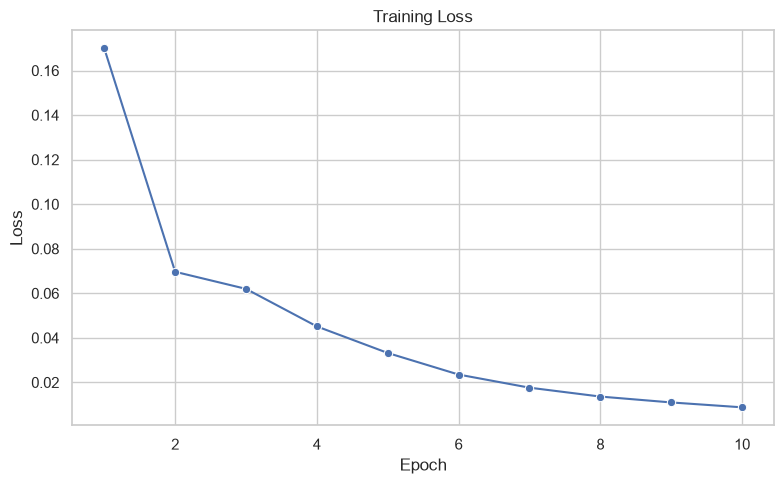

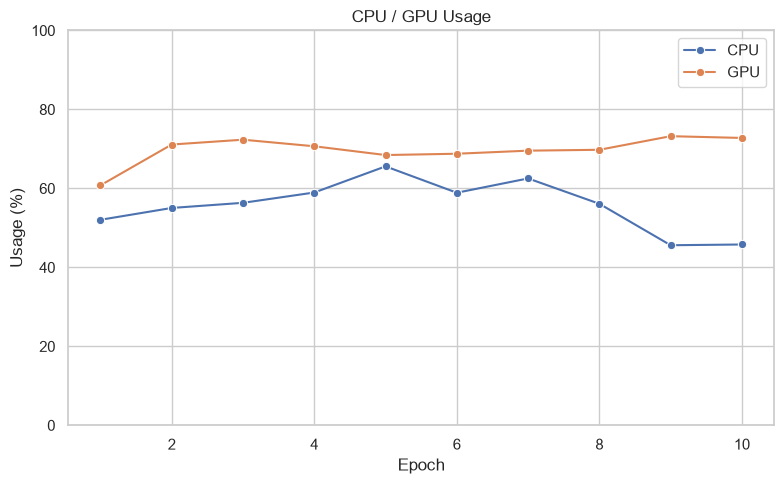

In [105]:
from util.visualize import plot_training_history

plot_training_history(history)

#### Train / Validation split (BaseLine)

In [ ]:
# Training configuration

BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_RATIO = 0.2

GPU_MEMORY_LIMIT = 90.0 


In [245]:
# ============================================================
# Train / Validation Split
# ============================================================

from torch.utils.data import random_split, DataLoader

dataset_size = len(dataset)

validation_size = int(dataset_size * VALIDATION_RATIO)
train_size = dataset_size - validation_size

train_dataset, validation_dataset = random_split(
    dataset,
    [train_size, validation_size]
)

print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(validation_dataset)}")


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Train: 116
Validation: 28


In [328]:
validation_model  = ConvAutoencoder().to(device)

validation_optimizer  = torch.optim.Adam(
    validation_model .parameters(),
    lr=LEARNING_RATE
)

In [ ]:
# ============================================================
# Validation Training
# ============================================================

import time

from util.monitor import (
    get_cpu_usage,
    get_ram_usage,
    get_gpu_usage
)


history = {
    "epoch": [],
    "train_loss": [],
    "validation_loss": [],
    "cpu": [],
    "ram": [],
    "gpu": [],
    "epoch_time": []
}


for epoch in range(NUM_EPOCHS):

    # ========================================================
    # Training
    # ========================================================

    validation_model .train()

    train_loss = 0.0

    cpu_usage = []
    ram_usage = []
    gpu_usage = []

    # epoch 시작 시간
    epoch_start = time.perf_counter()

    # ============================================================
    # DataLoader Selection
    # ============================================================

    training_loader = train_loader
    # training_loader = augmented_train_loader


    for dirty_batch, clean_batch, mask_batch in training_loader:

        # GPU/CPU로 이동
        dirty_batch = dirty_batch.to(device)
        clean_batch = clean_batch.to(device)
        mask_batch = mask_batch.to(device)

        validation_optimizer.zero_grad()

        output = validation_model (dirty_batch)

        pixel_loss = F.mse_loss(
            output,
            clean_batch,
            reduction="none"
        )

        loss = (
            pixel_loss * mask_batch
        ).sum() / mask_batch.sum().clamp_min(1)

        loss.backward()

        validation_optimizer.step()

        train_loss += loss.item()

        # CPU / RAM / GPU 사용률 기록
        cpu_usage.append(get_cpu_usage())
        ram_usage.append(get_ram_usage())
        gpu_usage.append(get_gpu_usage())


    # epoch 평균 Train Loss
    train_loss /= len(training_loader)


    # ========================================================
    # Validation
    # ========================================================

    validation_model.eval()

    validation_loss = 0.0

    with torch.no_grad():

        for dirty_batch, clean_batch, mask_batch in validation_loader:

            # GPU/CPU로 이동
            dirty_batch = dirty_batch.to(device)
            clean_batch = clean_batch.to(device)
            mask_batch = mask_batch.to(device)

            output = validation_model(dirty_batch)

            pixel_loss = F.mse_loss(
                output,
                clean_batch,
                reduction="none"
            )

            loss = (
                pixel_loss * mask_batch
            ).sum() / mask_batch.sum().clamp_min(1)

            validation_loss += loss.item()


    # epoch 평균 Validation Loss
    validation_loss /= len(validation_loader)


    # ========================================================
    # Epoch 종료
    # ========================================================

    epoch_time = time.perf_counter() - epoch_start

    # epoch 평균 CPU / RAM / GPU 사용률
    avg_cpu = sum(cpu_usage) / len(cpu_usage)
    avg_ram = sum(ram_usage) / len(ram_usage)
    avg_gpu = sum(gpu_usage) / len(gpu_usage)


    # ========================================================
    # History 저장
    # ========================================================

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["cpu"].append(avg_cpu)
    history["ram"].append(avg_ram)
    history["gpu"].append(avg_gpu)
    history["epoch_time"].append(epoch_time)


    # ========================================================
    # 결과 출력
    # ========================================================

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {validation_loss:.6f} "
        f"CPU: {avg_cpu:.1f}% "
        f"RAM: {avg_ram:.1f}% "
        f"GPU: {avg_gpu:.1f}% "
        f"Time: {epoch_time:.2f}s"
    )

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.head()

,epoch,train_loss,validation_loss,cpu,ram,gpu,epoch_time
0,1,0.162627,0.089072,45.5250,80.2250,67.500,3.849586
1,2,0.072364,0.071019,48.7500,80.2125,69.625,3.580079
2,3,0.074740,0.072528,47.5375,80.2250,71.125,3.529030
3,4,0.070383,0.060305,50.5125,80.1500,71.625,3.554138
4,5,0.059546,0.056295,48.3500,80.1750,69.875,3.545784


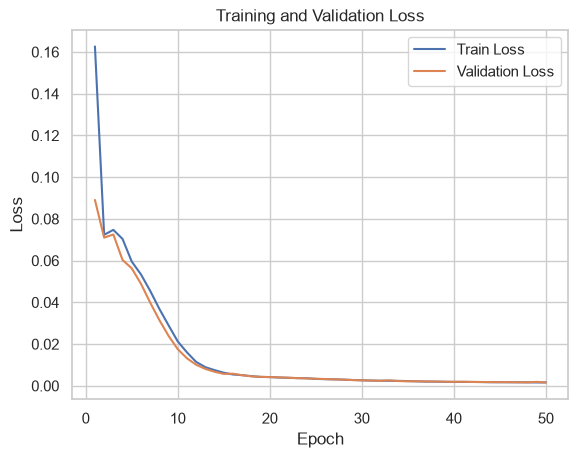

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(
    x=history["epoch"],
    y=history["train_loss"],
    label="Train Loss"
)

sns.lineplot(
    x=history["epoch"],
    y=history["validation_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [119]:
import copy

experiment_history = {
    "validation_adam_50": {
        "config": {
            "batch_size": 16,
            "learning_rate": 0.001,
            "optimizer": "Adam",
            "num_epochs": 50
        },
        "history": copy.deepcopy(history)
    }
}

print(experiment_history.keys())

dict_keys(['validation_adam_50'])


### 3. Model 학습 

#### optimizer 실험<br>
adam, SGD <br>
Adam: Epoch 50 / 100<br>
SGD: Epoch 50 / 100<br>
SGD: Learning Rate 0.01 / 0.1 (Epoch 100)
- 최종 : adam, 100 , 0.001 선택

In [242]:
# ============================================================
# Hyperparameter Experiments
# ============================================================

BATCH_SIZE = 16
LEARNING_RATE = 0.001

experiment_configs = {
    "adam_50": {
        "optimizer": "Adam",
        "num_epochs": 50
    },
    "adam_100": {
        "optimizer": "Adam",
        "num_epochs": 100
    },
    "sgd_50": {
        "optimizer": "SGD",
        "num_epochs": 50
    },
    "sgd_100": {
        "optimizer": "SGD",
        "num_epochs": 100
    },
    "sgd_lr001_100": {
        "optimizer": "SGD",
        "num_epochs": 100,
        "learning_rate": 0.01
    },
    "sgd_lr01_100": {
        "optimizer": "SGD",
        "num_epochs": 100,
        "learning_rate": 0.1
    }    
}

experiment_configs

{'adam_50': {'optimizer': 'Adam', 'num_epochs': 50},
 'adam_100': {'optimizer': 'Adam', 'num_epochs': 100},
 'sgd_50': {'optimizer': 'SGD', 'num_epochs': 50},
 'sgd_100': {'optimizer': 'SGD', 'num_epochs': 100},
 'sgd_lr001_100': {'optimizer': 'SGD',
  'num_epochs': 100,
  'learning_rate': 0.01},
 'sgd_lr01_100': {'optimizer': 'SGD', 'num_epochs': 100, 'learning_rate': 0.1}}

In [196]:
from dataclasses import dataclass


@dataclass
class EpochResult:
    experiment_name: str
    epoch: int
    num_epochs: int
    train_loss: float
    validation_loss: float
    cpu_usage: float
    ram_usage: float
    gpu_usage: float
    vram_usage: float
    epoch_time: float

In [197]:
# ============================================================
# Epoch History
# ============================================================

def save_epoch_history(
    history_data,
    result: EpochResult
):
    """
    Epoch 결과를 History에 저장합니다.
    """

    history_data["epoch"].append(
        result.epoch
    )

    history_data["train_loss"].append(
        result.train_loss
    )

    history_data["validation_loss"].append(
        result.validation_loss
    )

    history_data["cpu"].append(
        result.cpu_usage
    )

    history_data["ram"].append(
        result.ram_usage
    )

    history_data["gpu"].append(
        result.gpu_usage
    )

    history_data["vram"].append(
        result.vram_usage
    )

    history_data["epoch_time"].append(
        result.epoch_time
    ) 


In [198]:
# ============================================================
# Epoch Result
# ============================================================

def print_epoch_result(result: EpochResult):
    """
    Epoch 결과를 출력합니다.
    """

    print(
        f"[{result.experiment_name}] "
        f"Epoch [{result.epoch}/{result.num_epochs}] "
        f"Train: {result.train_loss:.6f} "
        f"Val: {result.validation_loss:.6f} "
        f"CPU: {result.cpu_usage:.1f}% "
        f"RAM: {result.ram_usage:.1f}% "
        f"GPU: {result.gpu_usage:.1f}% "
        f"VRAM: {result.vram_usage:.1f}% "
        f"Time: {result.epoch_time:.2f}s"
    ) 


##### 모델학습모듈(run_experiment)


In [336]:
# ============================================================
# Experiment Training Function
# ============================================================

import gc
import time

import torch
import torch.nn.functional as F

from util.resource_safety import (
    check_resource_safety,
    RAM_LIMIT,
    VRAM_LIMIT
)

from util.experiment import record_resource_usage


def run_experiment(
    experiment_name,
    optimizer_name,
    num_epochs,
    learning_rate=LEARNING_RATE,
    model_class=ConvAutoencoder,
    loss_name="MSE", 
    train_loader_override=None
):
    # --------------------------------------------------------
    # Loss 선택
    # --------------------------------------------------------

    if loss_name == "MSE":
        loss_function = F.mse_loss
    elif loss_name == "L1":
        loss_function = F.l1_loss
    elif loss_name == "SmoothL1":
        loss_function = F.smooth_l1_loss
    else:
        raise ValueError(
            f"Unsupported loss: {loss_name}"
        )

    # --------------------------------------------------------
    # Best Model 관리
    # --------------------------------------------------------

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = 0

    training_stopped = False
    stop_reason = None

    # --------------------------------------------------------
    # 새 모델 생성
    # --------------------------------------------------------

    experiment_model = model_class().to(device)

    # --------------------------------------------------------
    # GPU 정보 확인
    # --------------------------------------------------------

    if torch.cuda.is_available():
        gpu_total_memory = (
            torch.cuda.get_device_properties(device).total_memory
            / 1024**3
        )
    else:
        gpu_total_memory = 0.0

    # --------------------------------------------------------
    # 새 Optimizer 생성
    # --------------------------------------------------------

    if optimizer_name == "Adam":
        experiment_optimizer = torch.optim.Adam(
            experiment_model.parameters(),
            lr=learning_rate
        )
    elif optimizer_name == "SGD":
        experiment_optimizer = torch.optim.SGD(
            experiment_model.parameters(),
            lr=learning_rate
        )
    else:
        raise ValueError(
            f"Unsupported optimizer: {optimizer_name}"
        )

    # --------------------------------------------------------
    # 실험 결과 저장 공간 생성
    # --------------------------------------------------------

    experiment_history[experiment_name] = {
        "config": {
            "batch_size": BATCH_SIZE,
            "learning_rate": learning_rate,
            "optimizer": optimizer_name,
            "loss": loss_name,
            "num_epochs": num_epochs,
            "model": model_class.__name__,
            "ram_limit": RAM_LIMIT,
            "vram_limit": VRAM_LIMIT
        },
        "history": {
            "epoch": [],
            "train_loss": [],
            "validation_loss": [],
            "cpu": [],
            "ram": [],
            "gpu": [],
            "vram": [],
            "epoch_time": []
        }
    }

    history_data = experiment_history[
        experiment_name
    ]["history"]

    # ========================================================
    # Training
    # ========================================================

    for epoch in range(num_epochs):

        experiment_model.train()
        epoch_loss = 0.0

        cpu_usage = []
        ram_usage = []
        gpu_usage = []
        vram_usage = []

        epoch_start = time.perf_counter()

        # ============================================================
        # DataLoader Selection
        # ============================================================

        # training_loader = train_loader
        
        training_loader = (
            train_loader
            if train_loader_override is None
            else train_loader_override
        )        

        # ----------------------------------------------------
        # Batch Training
        # ----------------------------------------------------

        for dirty_batch, clean_batch, mask_batch in training_loader:

            # -----------------------------------------------
            # Resource Safety Check
            # -----------------------------------------------

            safe, reason = check_resource_safety(device)

            if not safe:
                training_stopped = True
                stop_reason = reason

                print(
                    f"\n[{experiment_name}] "
                    f"Training stopped: {stop_reason}"
                )
                break

            try:
                # -------------------------------------------
                # GPU 데이터 이동
                # -------------------------------------------

                dirty_batch = dirty_batch.to(device)
                clean_batch = clean_batch.to(device)
                mask_batch = mask_batch.to(device)

                # -------------------------------------------
                # Resource Safety Check
                # -------------------------------------------

                safe, reason = check_resource_safety(device)

                if not safe:
                    training_stopped = True
                    stop_reason = reason

                    print(
                        f"\n[{experiment_name}] "
                        f"Training stopped: {stop_reason}"
                    )
                    break

                # -------------------------------------------
                # Gradient 초기화
                # -------------------------------------------

                experiment_optimizer.zero_grad()

                # -------------------------------------------
                # Forward
                # -------------------------------------------

                output = experiment_model(
                    dirty_batch
                )

                # -------------------------------------------
                # Resource Safety Check
                # -------------------------------------------

                safe, reason = check_resource_safety(device)

                if not safe:
                    training_stopped = True
                    stop_reason = reason

                    print(
                        f"\n[{experiment_name}] "
                        f"Training stopped: {stop_reason}"
                    )
                    break

                # -------------------------------------------
                # Pixel-level Loss
                # -------------------------------------------

                pixel_loss = loss_function(
                    output,
                    clean_batch,
                    reduction="none"
                )

                # -------------------------------------------
                # Mask 적용
                # -------------------------------------------

                loss = (
                    pixel_loss * mask_batch
                ).sum() / mask_batch.sum().clamp_min(1)

                # -------------------------------------------
                # Backward
                # -------------------------------------------

                loss.backward()

                # -------------------------------------------
                # Parameter Update
                # -------------------------------------------

                experiment_optimizer.step()

                # -------------------------------------------
                # Epoch Loss 누적
                # -------------------------------------------

                epoch_loss += loss.item()

                # -------------------------------------------
                # Resource Usage 기록
                # -------------------------------------------

                record_resource_usage(
                    device=device,
                    gpu_total_memory=gpu_total_memory,
                    cpu_usage=cpu_usage,
                    ram_usage=ram_usage,
                    gpu_usage=gpu_usage,
                    vram_usage=vram_usage
                )

                # -------------------------------------------
                # Resource Safety Check
                # -------------------------------------------

                safe, reason = check_resource_safety(device)

                if not safe:
                    training_stopped = True
                    stop_reason = reason

                    print(
                        f"\n[{experiment_name}] "
                        f"Training stopped: {stop_reason}"
                    )
                    break

            # ------------------------------------------------
            # CUDA Out Of Memory
            # ------------------------------------------------

            except torch.cuda.OutOfMemoryError:

                training_stopped = True
                stop_reason = "CUDA Out Of Memory"

                print(
                    f"\n[{experiment_name}] "
                    f"Training stopped: {stop_reason}"
                )
                break

        # ----------------------------------------------------
        # 자원 부족으로 Training 중단
        # ----------------------------------------------------

        if training_stopped:
            break

        # ----------------------------------------------------
        # Epoch 종료
        # ----------------------------------------------------

        epoch_time = (
            time.perf_counter()
            - epoch_start
        )

        epoch_loss /= len(training_loader)

        # ====================================================
        # Validation
        # ====================================================

        experiment_model.eval()

        validation_loss = 0.0
        validation_batches = 0

        with torch.no_grad():

            for dirty_batch, clean_batch, mask_batch in validation_loader:

                # -------------------------------------------
                # Resource Safety Check
                # -------------------------------------------

                safe, reason = check_resource_safety(device)

                if not safe:
                    training_stopped = True
                    stop_reason = reason

                    print(
                        f"\n[{experiment_name}] "
                        f"Validation stopped: {stop_reason}"
                    )
                    break

                try:
                    # ---------------------------------------
                    # GPU 데이터 이동
                    # ---------------------------------------

                    dirty_batch = dirty_batch.to(device)
                    clean_batch = clean_batch.to(device)
                    mask_batch = mask_batch.to(device)

                    # ---------------------------------------
                    # Forward
                    # ---------------------------------------

                    output = experiment_model(
                        dirty_batch
                    )

                    # ---------------------------------------
                    # Pixel-level Loss
                    # ---------------------------------------

                    pixel_loss = loss_function(
                        output,
                        clean_batch,
                        reduction="none"
                    )

                    # ---------------------------------------
                    # Mask 적용
                    # ---------------------------------------

                    loss = (
                        pixel_loss * mask_batch
                    ).sum() / mask_batch.sum().clamp_min(1)

                    validation_loss += loss.item()
                    validation_batches += 1

                    # ---------------------------------------
                    # Resource Safety Check
                    # ---------------------------------------

                    safe, reason = check_resource_safety(device)

                    if not safe:
                        training_stopped = True
                        stop_reason = reason

                        print(
                            f"\n[{experiment_name}] "
                            f"Validation stopped: {stop_reason}"
                        )
                        break

                # -------------------------------------------
                # CUDA Out Of Memory
                # -------------------------------------------

                except torch.cuda.OutOfMemoryError:

                    training_stopped = True
                    stop_reason = (
                        "CUDA Out Of Memory during validation"
                    )

                    print(
                        f"\n[{experiment_name}] "
                        f"Validation stopped: {stop_reason}"
                    )
                    break

        # ----------------------------------------------------
        # Validation 중단
        # ----------------------------------------------------

        if training_stopped:
            break

        if validation_batches == 0:
            break

        validation_loss /= validation_batches

        # ====================================================
        # Best Model 저장
        # ====================================================

        if validation_loss < best_val_loss:

            best_val_loss = validation_loss
            best_epoch = epoch + 1

            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value
                in experiment_model.state_dict().items()
            }

        # ====================================================
        # 평균 Resource Usage
        # ====================================================

        avg_cpu = (
            sum(cpu_usage) / len(cpu_usage)
            if cpu_usage else 0.0
        )

        avg_ram = (
            sum(ram_usage) / len(ram_usage)
            if ram_usage else 0.0
        )

        avg_gpu = (
            sum(gpu_usage) / len(gpu_usage)
            if gpu_usage else 0.0
        )

        avg_vram = (
            sum(vram_usage) / len(vram_usage)
            if vram_usage else 0.0
        )

        # ====================================================
        # Epoch Result 생성
        # ====================================================

        epoch_result = EpochResult(
            experiment_name=experiment_name,
            epoch=epoch + 1,
            num_epochs=num_epochs,
            train_loss=epoch_loss,
            validation_loss=validation_loss,
            cpu_usage=avg_cpu,
            ram_usage=avg_ram,
            gpu_usage=avg_gpu,
            vram_usage=avg_vram,
            epoch_time=epoch_time
        )

        # ====================================================
        # History 저장
        # ====================================================

        save_epoch_history(
            history_data,
            epoch_result
        )

        # ====================================================
        # 결과 출력
        # ====================================================

        print_epoch_result(
            epoch_result
        )

    # ========================================================
    # 자원 부족으로 학습 중단된 경우
    # ========================================================

    if training_stopped:

        print()
        print(
            f"[{experiment_name}] "
            f"Experiment stopped safely."
        )

        print(
            f"Reason: {stop_reason}"
        )

    # ========================================================
    # Best Model 확인
    # ========================================================

    if best_model_state is None:

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        gc.collect()

        raise RuntimeError(
            f"[{experiment_name}] "
            f"No valid Best Model was saved. "
            f"Reason: {stop_reason}"
        )

    # ========================================================
    # Best Model 복원
    # ========================================================

    experiment_model.load_state_dict(
        best_model_state
    )

    experiment_model.to(device)

    # ========================================================
    # Best 결과 저장
    # ========================================================

    experiment_history[experiment_name]["best"] = {
        "epoch": best_epoch,
        "validation_loss": best_val_loss,
        "stopped": training_stopped,
        "stop_reason": stop_reason
    }

    # ========================================================
    # Best Model 결과 출력
    # ========================================================

    print()

    print(
        f"[{experiment_name}] "
        f"Best Epoch: {best_epoch} "
        f"Best Validation Loss: "
        f"{best_val_loss:.10f}"
    )

    if training_stopped:

        print(
            f"[{experiment_name}] "
            f"Training stopped early: "
            f"{stop_reason}"
        )

    # ========================================================
    # GPU Memory 정리
    # ========================================================

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    # ========================================================
    # Best Model 반환
    # ========================================================

    return experiment_model

##### A — Adam / LR 0.001 / 50 Epoch (  Best Validation Loss: 0.0014777897158637643 )

In [ ]:
adam_50_model = run_experiment(
    experiment_name="adam_50",
    optimizer_name="Adam",
    num_epochs=50
)

##### B — Adam / LR 0.001 / 100 Epoch (  Best Validation Loss: 0.001171758456621319 )

In [ ]:
adam_100_model = run_experiment(
    experiment_name="adam_100",
    optimizer_name="Adam",
    num_epochs=100
)

##### C — SGD / LR 0.001 / 50 Epoch (  Best Validation Loss: 0.10798535123467445 )

In [ ]:
sgd_50_model = run_experiment(
    experiment_name="sgd_50",
    optimizer_name="SGD",
    num_epochs=50
)

##### D — SGD / LR 0.001 / 100 Epoch (  Best Validation Loss: 0.06151258014142513)

In [ ]:
sgd_100_model = run_experiment(
    experiment_name="sgd_100",
    optimizer_name="SGD",
    num_epochs=100
)

In [ ]:
# import importlib
# import util.visualize

# importlib.reload(util.visualize)

# # del experiment_history["temp_test"]

<module 'util.visualize' from 'd:\\코드잇_과제\\util\\visualize.py'>

In [138]:
# ============================================================
# Experiment Summary
# ============================================================

import pandas as pd

summary = []

for experiment_name in [
    "adam_50",
    "adam_100",
    "sgd_50",
    "sgd_100"
]:

    config = experiment_history[experiment_name]["config"]
    history_data = experiment_history[experiment_name]["history"]

    validation_losses = history_data["validation_loss"]

    best_index = validation_losses.index(
        min(validation_losses)
    )

    summary.append({
        "experiment": experiment_name,
        "optimizer": config["optimizer"],
        "epochs": config["num_epochs"],
        "learning_rate": config["learning_rate"],
        "best_val_loss": validation_losses[best_index],
        "best_epoch": history_data["epoch"][best_index],
        "final_val_loss": validation_losses[-1],
        "total_time": sum(history_data["epoch_time"]),
        "avg_cpu": sum(history_data["cpu"]) / len(history_data["cpu"]),
        "avg_ram": sum(history_data["ram"]) / len(history_data["ram"]),
        "avg_gpu": sum(history_data["gpu"]) / len(history_data["gpu"])
    })

summary_df = pd.DataFrame(summary)

summary_df

,experiment,optimizer,epochs,learning_rate,best_val_loss,best_epoch,final_val_loss,total_time,avg_cpu,avg_ram,avg_gpu
0,adam_50,Adam,50,0.001,0.001478,50,0.001478,163.349816,50.546000,81.589750,69.40250
1,adam_100,Adam,100,0.001,0.001119,99,0.001243,331.490504,50.863000,80.582125,68.72375
2,sgd_50,SGD,50,0.001,0.107985,50,0.107985,162.385678,52.343500,83.242250,69.79750
3,sgd_100,SGD,100,0.001,0.061513,100,0.061513,324.200958,50.908125,81.982000,69.91125


In [ ]:
sgd_lr001_100_model = run_experiment(
    experiment_name="sgd_lr001_100",
    optimizer_name="SGD",
    num_epochs=100,
    learning_rate=0.01
)

In [ ]:
sgd_lr01_100_model = run_experiment(
    experiment_name="sgd_lr01_100",
    optimizer_name="SGD",
    num_epochs=100,
    learning_rate=0.1
)

##### Optimizer / Epoch 실험 그래프

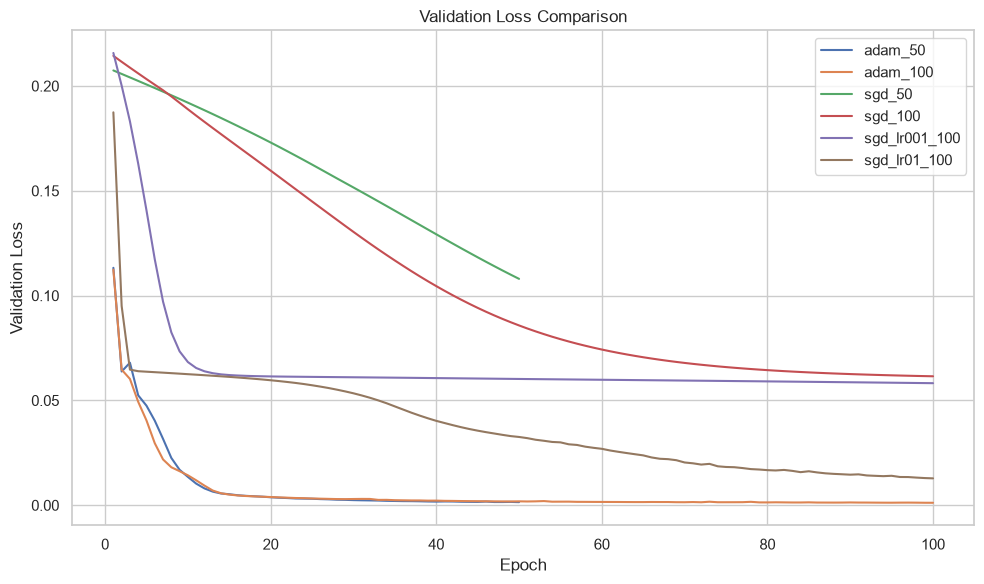

In [ ]:
from util.visualize import plot_experiment_validation_loss
 
plot_experiment_validation_loss(
    experiment_history,
    experiment_names=[
        "adam_50",
        "adam_100",
        "sgd_50",
        "sgd_100",
        "sgd_lr001_100",
        "sgd_lr01_100" 

    ]
)  

#### 학습내용 저장(json)

In [ ]:
# ============================================================
# Save Experiment Results
# ============================================================

import json
from pathlib import Path


# ------------------------------------------------------------
# 1. 결과 저장 폴더
# ------------------------------------------------------------

RESULT_DIR = Path("results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. 파일 저장
# ------------------------------------------------------------

# result_file = RESULT_DIR / "experiment_history_xx.json"

with open(result_file, "w", encoding="utf-8") as f:
    json.dump(
        experiment_history,
        f,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# 3. 저장 확인
# ------------------------------------------------------------

print(f"실험 결과 저장 완료: {result_file}")

실험 결과 저장 완료: results\experiment_history_260914.json


## 4. 이미지 복원
- adam_100_model  선정 : Best Validation Loss: 0.001171758456621319 

#### adam_100 모델 이미지복원

In [235]:
# ============================================================
# Image Restoration Visualization
# ============================================================

import matplotlib.pyplot as plt
import torch


def show_restoration_result(
    model,
    dataset,
    index=0
):
    """Dirty / Restored / Clean 이미지를 비교합니다."""

    model.eval()

    # 데이터 가져오기
    dirty_image, clean_image, mask = dataset[index]

    # Batch 차원 추가
    dirty_input = dirty_image.unsqueeze(0).to(device)

    # 이미지 복원
    with torch.no_grad():
        restored_image = model(dirty_input)

    # GPU → CPU
    dirty_image = dirty_image.cpu()
    clean_image = clean_image.cpu()
    restored_image = restored_image.squeeze(0).cpu()

    # [C, H, W] → [H, W, C]
    dirty_image = dirty_image.permute(1, 2, 0)
    restored_image = restored_image.permute(1, 2, 0)
    clean_image = clean_image.permute(1, 2, 0)

    # 이미지 값 범위 제한
    dirty_image = dirty_image.clamp(0, 1)
    restored_image = restored_image.clamp(0, 1)
    clean_image = clean_image.clamp(0, 1)

    # 시각화
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(dirty_image)
    axes[0].set_title("Dirty Image")
    axes[0].axis("off")

    axes[1].imshow(restored_image)
    axes[1].set_title("Restored Image")
    axes[1].axis("off")

    axes[2].imshow(clean_image)
    axes[2].set_title("Clean Image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [381]:
def restoration_result ( result_model, result  ) :
    experiment_results[result_model] = result

    for index in range(3):
        show_restoration_result(
            model=experiment_results[result_model],
            dataset=validation_dataset,
            index=index
        )

In [ ]:
 
restoration_result( "adam_100", adam_100_model ) 

In [384]:
# 위 모델을 cpu로 이전 (GPU 자원 이슈)
# adam_100_model = adam_100_model.cpu()
# adam_100_model = adam_100_model.cuda()

torch.cuda.empty_cache()
gc.collect()

50949

## 5. 이미지 보정
- 채도가 높고 명도가 낮은 이미지가 일부 얼룩처럼 남아있어 추가 보정작업필요 
- 실험항목<br>
    다운샘플링 후 1/16/32/48 테스트 : 노이즈 심함. 문제사항 해결안됨<br>
    위에 선정된 모델(Adam_100, lr=0.0001, mseLoss) -> loss 만 변경해서 테스트

#### Loss 비교 : Adam 100 + MSE, L1, SmoothL1

In [385]:
# ============================================================
# Loss Function Experiments - Base Model
# ============================================================

# BATCH_SIZE = 16
# LEARNING_RATE = 0.001

loss_experiment_configs = {
    "adam_100_mse": {
        "optimizer": "Adam",
        "num_epochs": 100,
        "model_class": ConvAutoencoder,
        "loss": "MSE"
    },
    "adam_100_l1": {
        "optimizer": "Adam",
        "num_epochs": 100,
        "model_class": ConvAutoencoder,
        "loss": "L1"
    },
    "adam_100_smoothl1": {
        "optimizer": "Adam",
        "num_epochs": 100,
        "model_class": ConvAutoencoder,
        "loss": "SmoothL1"
    }
}

# loss_experiment_configs

In [ ]:
# ============================================================
# Run Loss Experiments
# ============================================================

experiment_results = {}

for experiment_name, config in loss_experiment_configs.items():

    result = run_experiment(
        experiment_name=experiment_name,
        optimizer_name=config["optimizer"],
        num_epochs=config["num_epochs"],
        learning_rate=config.get(
            "learning_rate",
            LEARNING_RATE
        ),
        model_class=config["model_class"],
        loss_name=config["loss"]
    )

    experiment_results[experiment_name] = result

In [297]:
adam_results = {
    name: result
    for name, result in experiment_results.items()
    if name.startswith("adam_")
}

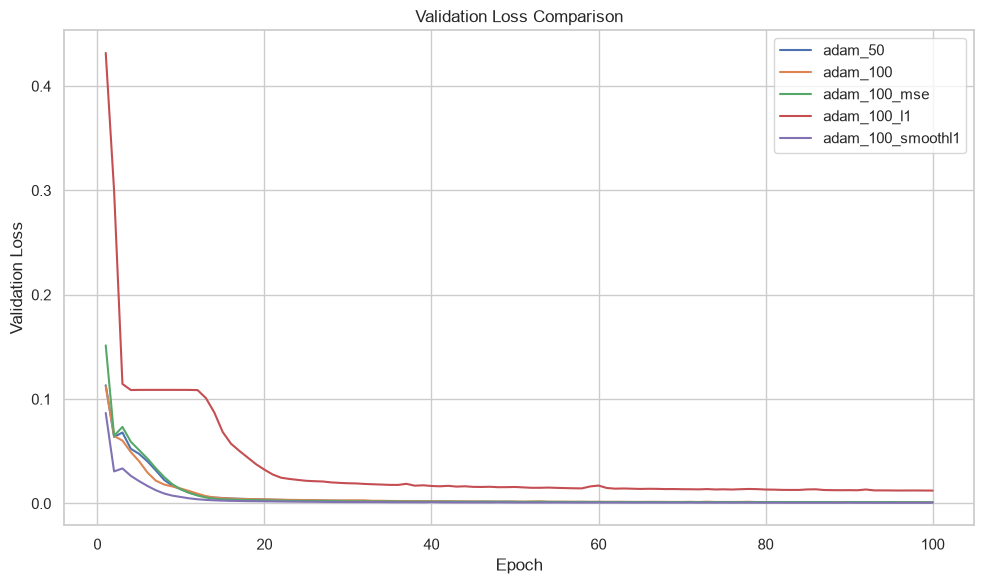

In [304]:
from util.visualize import plot_experiment_validation_loss

adam_history = {
    name: data
    for name, data in experiment_history.items()
    if name.startswith("adam_")
}

plot_experiment_validation_loss(
    adam_history
)

In [310]:
for name, data in experiment_history.items():
    if name.startswith("adam_") and "best" in data:
        print(
            f"{name}: "
            f"Best Loss = {data['best']['validation_loss']:.6f}, "
            f"Epoch = {data['best']['epoch']}"
        )

adam_100: Best Loss = 0.001172, Epoch = 100
adam_100_mse: Best Loss = 0.001178, Epoch = 100
adam_100_l1: Best Loss = 0.012335, Epoch = 100
adam_100_smoothl1: Best Loss = 0.000657, Epoch = 96


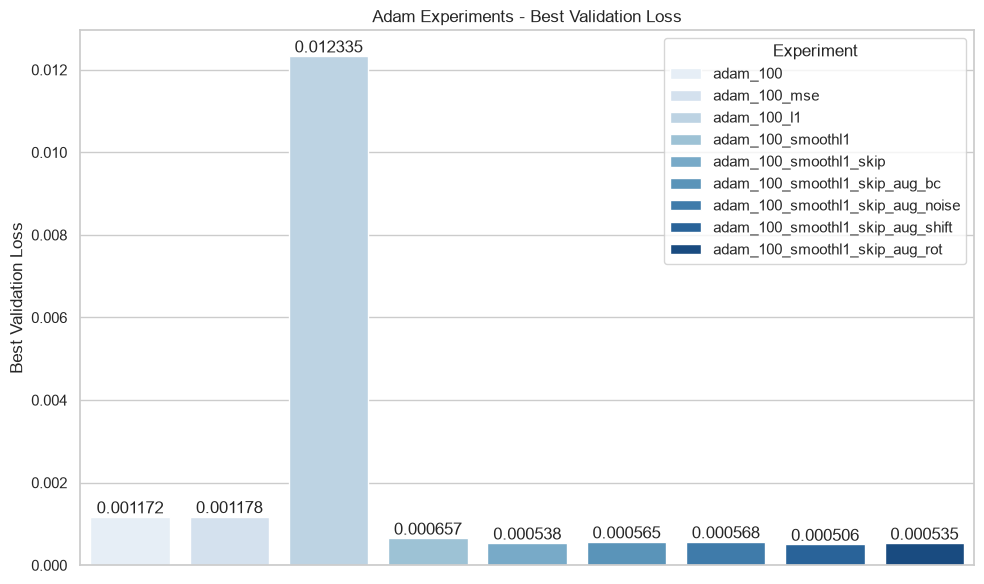

In [391]:
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Adam 실험 Best 결과 수집
# ------------------------------------------------------------

experiment_names = []
best_losses = []
best_epochs = []

for name, data in experiment_history.items():

    if name.startswith("adam_") and "best" in data:

        experiment_names.append(name)

        best_losses.append(
            data["best"]["validation_loss"]
        )

        best_epochs.append(
            data["best"]["epoch"]
        )


# ------------------------------------------------------------
# 그래프용 DataFrame
# ------------------------------------------------------------

import pandas as pd

plot_data = pd.DataFrame({
    "Experiment": experiment_names,
    "Best Loss": best_losses,
    "Best Epoch": best_epochs
})


# ------------------------------------------------------------
# Best Validation Loss 그래프
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    x="Experiment",
    y="Best Loss",
    hue="Experiment",
    palette="Blues",
    legend=True
)

plt.title("Adam Experiments - Best Validation Loss")
plt.xlabel("")
plt.ylabel("Best Validation Loss")

# x축 모델명 제거
ax.set_xticks([])

# 막대 위에 Loss 값 표시
for i, loss in enumerate(best_losses):
    ax.text(
        i,
        loss,
        f"{loss:.6f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 이미지보정 고도화 (ConvAutoencoderSkip)

- 채널, loss변경으로 얼룩제거에 실패  
- skip connection , Data Augmentation 적용 : 2가지다 차이 없으나 Skip이 좀더 loss가 작음

#### Skip Channection
- Skip Connection 적용 : Loss 최저. 육안으로는 유의미한 차이 없음

In [318]:
# ============================================================
# ConvAutoencoder with Skip Connection
# ============================================================

class ConvAutoencoderSkip(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.encoder2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.decoder1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Skip Connection 때문에 입력 채널이 16 + 16 = 32
        self.decoder2 = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)

        # Decoder
        d1 = self.decoder1(e2)

        # Skip Connection
        d1 = torch.cat([d1, e1], dim=1)

        # Output
        out = self.decoder2(d1)

        return out

In [320]:
loss_experiment_configs["adam_100_smoothl1_skip"] = {
    "optimizer": "Adam",
    "num_epochs": 100,
    "model_class": ConvAutoencoderSkip,
    "loss": "SmoothL1"
}

In [ ]:
result = run_experiment(
    experiment_name="adam_100_smoothl1_skip",
    optimizer_name="Adam",
    num_epochs=100,
    learning_rate=LEARNING_RATE,
    model_class=ConvAutoencoderSkip,
    loss_name="SmoothL1"
)

experiment_results["adam_100_smoothl1_skip"] = result

In [ ]:
restoration_result( "adam_100_smoothl1_skip", experiment_results["adam_100_smoothl1_skip"] ) 

#### Data Augmentation
- Adam + SmoothL1 + Skip Connection 
- 4가지 실험 : Brightness / Contrast, Noise, Small Shift, Small Rotation / Deformation 

In [332]:
# ============================================================
# Augmented Dataset
# ============================================================

from torch.utils.data import Dataset


class AugmentedDataset(Dataset):

    def __init__(
        self,
        dataset,
        augmentation
    ):
        self.dataset = dataset
        self.augmentation = augmentation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        dirty, clean, mask = self.dataset[index]

        if self.augmentation is not None:
            dirty, clean, mask = self.augmentation(
                dirty,
                clean,
                mask
            )

        return dirty, clean, mask

+ Brightness/Contrast ±10%  
Epoch: 99 Best Validation Loss: 0.0005651193

In [ ]:
# ============================================================
# Augmentation Train Dataset / DataLoader
# ============================================================

from util.denoising_augmentation import DenoisingAugmentation


augmentation_bc = DenoisingAugmentation(
    brightness=0.10,
    contrast=0.10,
    noise_std=0.0,
    max_shift=0,
    max_rotation=0.0
)

augmented_train_dataset_bc = AugmentedDataset(
    train_dataset,
    augmentation_bc
)

augmented_train_loader_bc = DataLoader(
    augmented_train_dataset_bc,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 실행
result_aug_bc = run_experiment(
    experiment_name="adam_100_smoothl1_skip_aug_bc",
    optimizer_name="Adam",
    num_epochs=100,
    learning_rate=0.001,
    model_class=ConvAutoencoderSkip,
    loss_name="SmoothL1",
    train_loader_override=augmented_train_loader_bc
)

In [ ]:
experiment_results["adam_100_smoothl1_skip_aug_bc"] = result_aug_bc
restoration_result("adam_100_smoothl1_skip_aug_bc",result_aug_bc )    

+ Noise σ=0.03 <br>Epoch: 93 Best Validation Loss: 0.0005676336

In [ ]:
# ============================================================
# Augmentation Experiment - Noise
# ============================================================

augmentation_noise = DenoisingAugmentation(
    brightness=0.0,
    contrast=0.0,
    noise_std=0.03,
    max_shift=0,
    max_rotation=0.0
)

augmented_train_dataset_noise = AugmentedDataset(
    train_dataset,
    augmentation_noise
)

augmented_train_loader_noise = DataLoader(
    augmented_train_dataset_noise,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 실행
result_aug_noise = run_experiment(
    experiment_name="adam_100_smoothl1_skip_aug_noise",
    optimizer_name="Adam",
    num_epochs=100,
    learning_rate=0.001,
    model_class=ConvAutoencoderSkip,
    loss_name="SmoothL1",
    train_loader_override=augmented_train_loader_noise
)

In [ ]:
experiment_results["adam_100_smoothl1_skip_aug_noise"] = result_aug_noise
restoration_result("adam_100_smoothl1_skip_aug_noise",result_aug_noise )

+ Shift ±5px<br>
Epoch: 100 Best Validation Loss: 0.0005063315

In [ ]:
# ============================================================
# Augmentation Experiment - Shift
# ============================================================

augmentation_shift = DenoisingAugmentation(
    brightness=0.0,
    contrast=0.0,
    noise_std=0.0,
    max_shift=5,
    max_rotation=0.0
)

augmented_train_dataset_shift = AugmentedDataset(
    train_dataset,
    augmentation_shift
)

augmented_train_loader_shift = DataLoader(
    augmented_train_dataset_shift,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 실행
result_aug_shift = run_experiment(
    experiment_name="adam_100_smoothl1_skip_aug_shift",
    optimizer_name="Adam",
    num_epochs=100,
    learning_rate=0.001,
    model_class=ConvAutoencoderSkip,
    loss_name="SmoothL1",
    train_loader_override=augmented_train_loader_shift
)

In [ ]:
experiment_results["adam_100_smoothl1_skip_aug_shift"] = result_aug_shift
restoration_result("adam_100_smoothl1_skip_aug_shift",result_aug_shift )

In [ ]:
# del experiment_results["adam_100_smoothl1"]
# del experiment_results["adam_100_smoothl1_skip_aug_bc"]

# import gc
# import torch

# # CPU RAM
# gc.collect()

# # GPU VRAM
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     torch.cuda.ipc_collect()

+ Rotation ±2°

In [ ]:
# ============================================================
# Augmentation Experiment - Rotation
# ============================================================

augmentation_rot = DenoisingAugmentation(
    brightness=0.0,
    contrast=0.0,
    noise_std=0.0,
    max_shift=0,
    max_rotation=2.0
)

augmented_train_dataset_rot = AugmentedDataset(
    train_dataset,
    augmentation_rot
)

augmented_train_loader_rot = DataLoader(
    augmented_train_dataset_rot,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 실행
result_aug_rot = run_experiment(
    experiment_name="adam_100_smoothl1_skip_aug_rot",
    optimizer_name="Adam",
    num_epochs=100,
    learning_rate=0.001,
    model_class=ConvAutoencoderSkip,
    loss_name="SmoothL1",
    train_loader_override=augmented_train_loader_rot
)

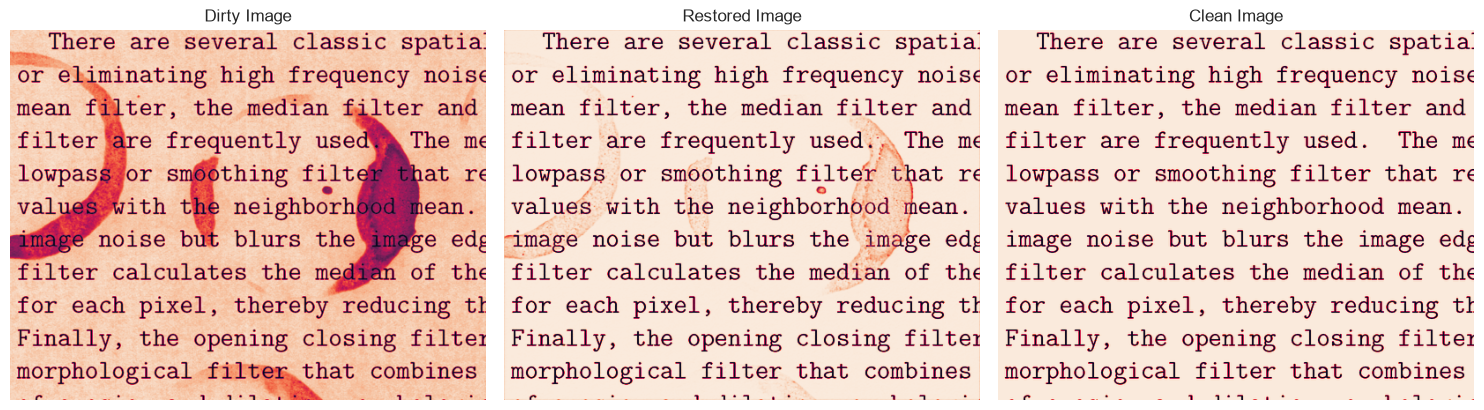

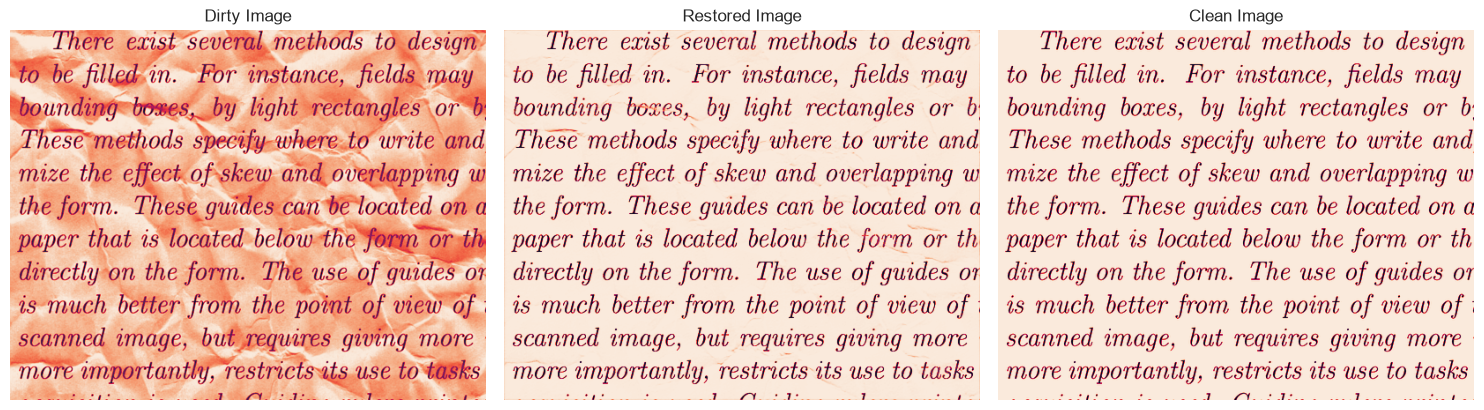

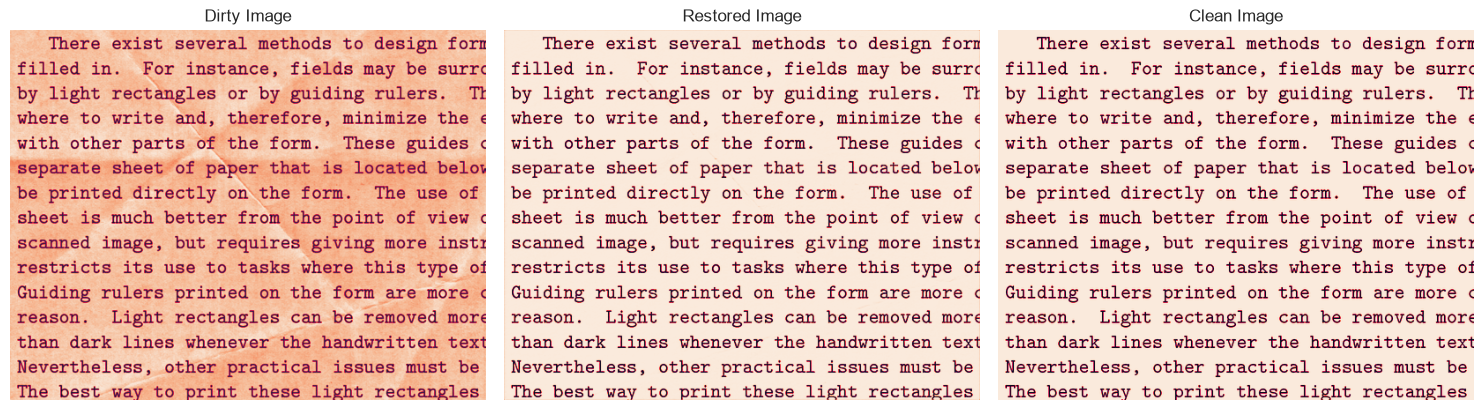

In [396]:
experiment_results["adam_100_smoothl1_skip_aug_rot"] = result_aug_rot
restoration_result("adam_100_smoothl1_skip_aug_rot",result_aug_rot )

#### Cache 정리

In [362]:
print(
    f"Allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"Reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

Allocated: 0.05 GB
Reserved: 0.35 GB


In [ ]:
# import importlib
# import util.resource_safety

# importlib.reload(util.resource_safety)

# from util.resource_safety import gc_clear

In [409]:
from util.resource_safety import gc_clear
 

print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved : {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

gc_clear()

print("----- after cleanup -----")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved : {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Allocated: 0.05 GB
Reserved : 0.16 GB
----- after cleanup -----
Allocated: 0.04 GB
Reserved : 0.13 GB
